In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import tensorflow as tf
from catboost import CatBoostRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid")

2026-04-27 07:40:15.967352: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777275616.380671      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777275616.509370      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777275617.577065      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777275617.577108      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777275617.577111      22 computation_placer.cc:177] computation placer alr

In [2]:
# ==========================================
# 1. LOAD RUL DATA & STRATIFIED LOBO SPLIT
# ==========================================
# IMPORTANT: Make sure this path points to the RUL dataset!
path = '/kaggle/input/notebooks/ckskaggle/eda-de/csv_exports/ML_Engineered_Battery_Dataset_RUL.csv'
df = pd.read_csv(path)

# The same 9 test batteries to keep the benchmark fair
test_batteries = ['B0005', 'B0025', 'B0029', 'B0033', 'B0038', 'B0041', 'B0045', 'B0049', 'B0053']
df_train = df[~df['Battery_ID'].isin(test_batteries)].copy()
df_test = df[df['Battery_ID'].isin(test_batteries)].copy()

# Features (X) and Target (y) - Target is RUL!
features = [
    'Cycle_Index', 'Ambient_Temperature', 'Discharge_Time_Seconds', 
    'Max_Temp_Reached', 'Min_Voltage_Recorded', 
    'Voltage_Drop_Rate_V_per_sec', 'Internal_Resistance_Re'
]
target = 'RUL'

X_train, y_train = df_train[features], df_train[target]
X_test, y_test = df_test[features], df_test[target]

print(f"Track B: Training to predict RUL on {len(df_train['Battery_ID'].unique())} batteries")

# Extract Battery B0005 for Testing Later
target_test_battery = 'B0005'
df_b0005 = df_test[df_test['Battery_ID'] == target_test_battery].copy()
X_b0005 = df_b0005[features]

Track B: Training to predict RUL on 25 batteries


## 1. The CatBoost Model (Tabular Powerhouse)
CatBoost is an incredible algorithm built by Yandex that rivals XGBoost. Since it is already installed on Kaggle, you can drop this right in:

In [3]:
# ==========================================
# 2. CATBOOST TRAINING
# ==========================================
print("\n--- Training CatBoost Network ---")
cat_model = CatBoostRegressor(iterations=500, learning_rate=0.05, task_type='GPU', random_seed=42, verbose=0)
cat_model.fit(X_train, y_train)

df_b0005['Pred_CatBoost'] = cat_model.predict(X_b0005)
mae_cat = mean_absolute_error(df_b0005['RUL'], df_b0005['Pred_CatBoost'])
print(f"CatBoost MAE: Off by an average of {mae_cat:.1f} cycles")


--- Training CatBoost Network ---
CatBoost MAE: Off by an average of 40.5 cycles


## 2. The LSTM Deep Learning Model (Keras / TensorFlow)
Because batteries degrade sequentially over time, predicting RUL is a Time-Series Sequence Problem. An LSTM (Long Short-Term Memory) neural network doesn't just look at one cycle; it looks at a "sliding window" of the past 10 cycles to understand the degradation trend.

This requires us to reshape the data from 2D (rows and columns) into 3D (samples, time-steps, features). Here is the complete code to prepare the sequences and train the LSTM:

In [4]:
# ==========================================
# 3. LSTM DEEP LEARNING TRAINING
# ==========================================
print("\n--- Training LSTM Network ---")

# Scale the data (Neural Networks require inputs between 0 and 1)
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
X_b0005_scaled = scaler_X.transform(X_b0005)

# Function to create "Sliding Windows" of past 10 cycles
def create_sequences(X, y, seq_length=10):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:(i + seq_length)])
        ys.append(y.iloc[i + seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 10
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, seq_length)

# Build the LSTM Architecture
lstm_model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(seq_length, X_train.shape[1])),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Output layer predicting RUL
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the Model
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)

# Benchmark LSTM on Battery B0005
# Note: we lose the first 10 cycles of B0005 because the LSTM needs 10 cycles to start predicting
X_b0005_seq, y_b0005_seq = create_sequences(X_b0005_scaled, df_b0005['RUL'], seq_length)
pred_lstm_b0005 = lstm_model.predict(X_b0005_seq)
mae_lstm = mean_absolute_error(y_b0005_seq, pred_lstm_b0005)
print(f"\nLSTM MAE: Off by an average of {mae_lstm:.1f} cycles")



--- Training LSTM Network ---


I0000 00:00:1777275667.937646      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13753 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777275667.942397      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13753 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30


I0000 00:00:1777275673.400553      82 service.cc:152] XLA service 0x782c580041b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777275673.400617      82 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777275673.400625      82 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777275674.248886      82 cuda_dnn.cc:529] Loaded cuDNN version 91002


25/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 46004.7617 - mae: 162.1664

I0000 00:00:1777275677.353376      82 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


65/65 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - loss: 43700.9727 - mae: 157.6676 - val_loss: 23783.9805 - val_mae: 119.6696
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22625.2383 - mae: 116.1727 - val_loss: 21786.0449 - val_mae: 113.1756
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20123.8906 - mae: 107.6351 - val_loss: 18661.0527 - val_mae: 100.9757
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16675.2832 - mae: 97.4865 - val_loss: 11133.3555 - val_mae: 77.5423
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 11181.9873 - mae: 78.6225 - val_loss: 8216.0049 - val_mae: 65.6382
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 10605.3711 - mae: 75.6183 - val_loss: 8879.9033 - val_mae: 67.2136
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9440.4971 - mae: 70.3801 - val_loss: 8473.1641 - val_mae: 69.0234
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9583.6787 - mae: 72.6124 - val_loss: 9713.0830 - val_mae: 70.1411
E

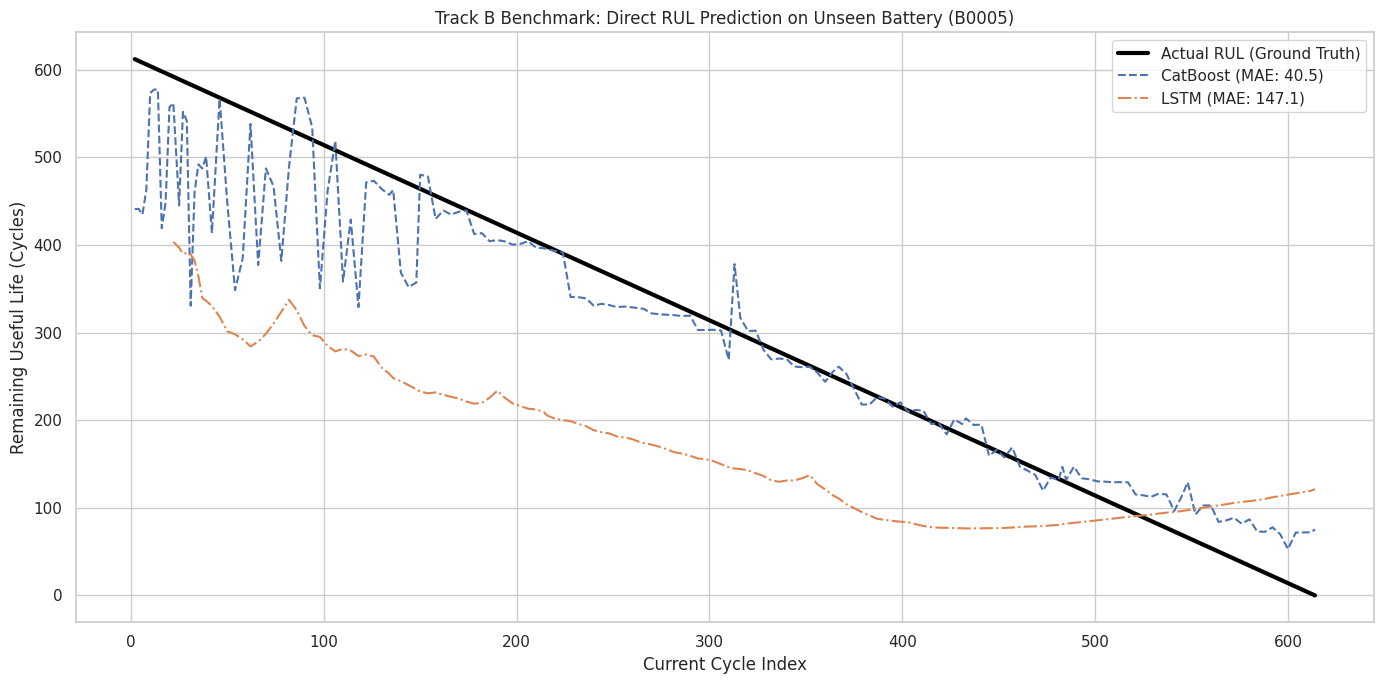

In [5]:
# ==========================================
# 4. PLOTTING THE COMPARISON
# ==========================================
plt.figure(figsize=(14, 7))
# Plot actual RUL
plt.plot(df_b0005['Cycle_Index'], df_b0005['RUL'], label='Actual RUL (Ground Truth)', color='black', linewidth=3)
# Plot CatBoost
plt.plot(df_b0005['Cycle_Index'], df_b0005['Pred_CatBoost'], label=f'CatBoost (MAE: {mae_cat:.1f})', linestyle='--')
# Plot LSTM (Note: LSTM predictions start at cycle index 10)
plt.plot(df_b0005['Cycle_Index'].iloc[seq_length:], pred_lstm_b0005, label=f'LSTM (MAE: {mae_lstm:.1f})', linestyle='-.')

plt.title(f"Track B Benchmark: Direct RUL Prediction on Unseen Battery ({target_test_battery})")
plt.xlabel("Current Cycle Index")
plt.ylabel("Remaining Useful Life (Cycles)")
plt.legend()
plt.tight_layout()
plt.show()



In [6]:
# ==========================================
# 5. SAVE ALL MODELS
# ==========================================
os.makedirs('saved_models', exist_ok=True)
joblib.dump(cat_model, 'saved_models/catboost_rul_model.pkl')
lstm_model.save('saved_models/lstm_rul_model.keras')
joblib.dump(scaler_X, 'saved_models/lstm_scaler.pkl')

print("\n✅ All Models Successfully Saved to Disk!")


✅ All Models Successfully Saved to Disk!
